# 10주차: 그래디언트 부스팅 & GridSearchCV
### 📊 데이터: sklearn breast_cancer → 유방암 양성/악성 분류 — 분류 문제
---
## 차시 1 — 그래디언트 부스팅 원리
- **배깅(9주차 복습)**: 병렬 + 독립 → 깊은 트리 → 분산↓ (편향 유지)
- **부스팅**: 순차 + 의존 → 얕은 트리 → **편향↓ + 분산↓**
- **잔차**: 실제값 − 예측값 = "아직 맞추지 못한 부분" → 다음 트리의 학습 대상
- **공식**: F_t = F_{t-1} + learning_rate × h_t (잔차 계산 → 트리 학습 → 누적 갱신, 반복)
- **세 핵심 HP**: `n_estimators`(트리 수, 기본 100), `learning_rate`(기여도, 기본 0.1), `max_depth`(깊이, 기본 3)
- **lr↓ → n↑ 보상 관계**: 총 학습량 유지. 한 번에 하나씩 조절이 원칙
- **약한 학습기를 합쳐 강한 학습기를 만든다** — Boosting 이름의 의미

## 차시 2 — GridSearchCV
- **문제**: 3개 파라미터 동시 튜닝 → for문 3중 중첩 + 결과 관리 어려움 + fold 일관성 문제
- **해결**: `GridSearchCV` — param_grid의 모든 조합을 교차검증으로 자동 평가
- **입력**: 모델(값 안 넣음) + param_grid(딕셔너리) + cv + scoring
- **출력**: `best_params_`, `best_score_`, `best_estimator_`(바로 predict 가능)
- **주의 3가지**: ① 조합 수 미리 계산 ② 경계값 확인 후 재탐색 ③ 전처리 누수 위험(Pipeline)

---
## Step 1. 라이브러리 임포트

In [1]:
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

print(f"scikit-learn: {sklearn.__version__}")
print(f"Python: {sys.version.split()[0]}")

scikit-learn: 1.6.1
Python: 3.12.12


---
## Step 2. 데이터 로드 및 탐색
- **데이터**: sklearn 내장 `breast_cancer` 데이터셋
- **피처 (30개)**: 종양의 크기·모양·밀도 등 세포핵 측정치
- **타겟**: 양성(1) / 악성(0) (이진 분류 → 정확도로 평가)
- **샘플 수**: 569개 → 훈련 455, 테스트 114 (8:2 분할)

**⚠ 트리 계열 모델은 피처 스케일에 무관 → 스케일링 불필요 (5주차와 다름)**

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"피처 수  : {X.shape[1]}")
print(f"샘플 수  : {X.shape[0]} (훈련 {X_train.shape[0]}, 테스트 {X_test.shape[0]})")
print(f"타겟 분포: 양성(1)={np.sum(y==1)}명({np.mean(y==1)*100:.1f}%), "
      f"악성(0)={np.sum(y==0)}명({np.mean(y==0)*100:.1f}%)")

피처 수  : 30
샘플 수  : 569 (훈련 455, 테스트 114)
타겟 분포: 양성(1)=357명(62.7%), 악성(0)=212명(37.3%)


In [3]:
# 피처 기초 통계 (상위 10개 피처만)
print("=== 피처 기초 통계 (상위 10개) ===")
df = pd.DataFrame(X, columns=data.feature_names)
df.iloc[:, :10].describe().round(4)

=== 피처 기초 통계 (상위 10개) ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
count,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628
std,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071
min,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500
25%,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577
50%,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615
75%,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661
max,28.1100,39.2800,188.500,2501.0000,0.1634,0.3454,0.4268,0.2012,0.3040,0.0974


---
## Step 3. 기준선 — 배깅 복습
- 9주차 핵심: 부트스트랩 샘플 → 독립 트리 → 다수결/평균 → **분산↓**
- 오늘 부스팅과 비교할 **기준선**으로 RandomForest 성능을 먼저 기록

| 배깅 키워드 | 부스팅 키워드 |
|-----------|------------|
| 병렬, 독립 | 순차, 의존 |
| 깊은 트리 (강한 학습기) | 얕은 트리 (약한 학습기) |
| 분산↓ 편향 유지 | **편향↓ + 분산↓** |

In [4]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
scores_rf = cross_val_score(rf_baseline, X_train, y_train, cv=5, scoring="accuracy")

print("RandomForest (n=100, 기본값):")
print(f"  CV 각 폴드 : {scores_rf.round(4)}")
print(f"  CV 평균    : {scores_rf.mean():.4f} ± {scores_rf.std():.4f}")
print()
print("→ 이 값이 부스팅과 비교할 기준선이다")

RandomForest (n=100, 기본값):
  CV 각 폴드 : [0.978  0.9451 0.978  0.956  0.9341]
  CV 평균    : 0.9582 ± 0.0176

→ 이 값이 부스팅과 비교할 기준선이다


---
## Step 4. 잔차 수치 예시 — 부스팅의 핵심 신호
- **잔차** = 실제값 − 예측값 = "아직 맞추지 못한 부분"
- 부스팅은 다음 트리에게 "원래 값을 예측해"가 아니라 **"이 잔차를 예측해"**라고 시킨다
- 초기 예측 = 전체 평균 (회귀 문제 기준)

| 비유 | 모의고사 틀린 문제만 집중 복습 → 다음 시험에서 점수 향상 |

In [5]:
actual = np.array([80, 65, 90, 50, 75])
students = ["A", "B", "C", "D", "E"]

initial_pred = actual.mean()  # 72.0
residuals = actual - initial_pred

df_res = pd.DataFrame({
    "실제 점수": actual,
    f"초기 예측 (평균={initial_pred:.0f})": initial_pred,
    "잔차 (실제−예측)": residuals,
}, index=students)

print("=== 잔차(Residual) 수치 예시 ===")
print(df_res.to_string())
print()
print("학생 A: 실제 80 − 예측 72 = +8  → '8점을 더 예측해야 한다'")
print("학생 D: 실제 50 − 예측 72 = −22 → '22점을 덜 예측해야 한다'")
print()
print("→ 부스팅의 다음 트리는 이 잔차를 예측하는 것이 목표")

=== 잔차(Residual) 수치 예시 ===
   실제 점수  초기 예측 (평균=72)  잔차 (실제−예측)
A     80           72.0         8.0
B     65           72.0        -7.0
C     90           72.0        18.0
D     50           72.0       -22.0
E     75           72.0         3.0

학생 A: 실제 80 − 예측 72 = +8  → '8점을 더 예측해야 한다'
학생 D: 실제 50 − 예측 72 = −22 → '22점을 덜 예측해야 한다'

→ 부스팅의 다음 트리는 이 잔차를 예측하는 것이 목표


---
## Step 5. 잔차 보완 시뮬레이션 — 매 단계 잔차 감소
- 공식: **F_t = F_{t-1} + learning_rate × h_t**
- 잔차 계산 → 작은 트리 학습 → 누적 예측 갱신, 이 3단계를 반복
- 시뮬레이션: 가상의 트리가 잔차의 80%를 대략 예측한다고 가정

### 기대 패턴
| 단계 | 잔차 크기 | 의미 |
|------|-----------|------|
| 초기 | 크다 (MAE ≈ 12) | 예측이 평균에 고정 |
| Step 1~5 | 줄어든다 | 트리가 잔차를 보완 |
| Step N | ≈ 0 | 예측 ≈ 실제값 |

In [6]:
actual = np.array([80, 65, 90, 50, 75], dtype=float)
lr = 0.1

pred = np.full_like(actual, actual.mean())
residual = actual - pred

print("=== 그래디언트 부스팅 시뮬레이션 (lr=0.1) ===")
print(f"초기 — 잔차: {residual}, MAE: {np.mean(np.abs(residual)):.1f}")

for step in range(1, 6):
    tree_pred = residual * 0.8  # 가상 트리: 잔차의 80% 예측
    pred = pred + lr * tree_pred
    residual = actual - pred
    print(
        f"Step {step} — 잔차: {np.round(residual, 2)}, "
        f"MAE: {np.mean(np.abs(residual)):.2f}"
    )

print()
print("→ 반복할수록 잔차가 줄어들고, 예측이 실제값에 수렴")

=== 그래디언트 부스팅 시뮬레이션 (lr=0.1) ===
초기 — 잔차: [  8.  -7.  18. -22.   3.], MAE: 11.6
Step 1 — 잔차: [  7.36  -6.44  16.56 -20.24   2.76], MAE: 10.67
Step 2 — 잔차: [  6.77  -5.92  15.24 -18.62   2.54], MAE: 9.82
Step 3 — 잔차: [  6.23  -5.45  14.02 -17.13   2.34], MAE: 9.03
Step 4 — 잔차: [  5.73  -5.01  12.9  -15.76   2.15], MAE: 8.31
Step 5 — 잔차: [  5.27  -4.61  11.86 -14.5    1.98], MAE: 7.65

→ 반복할수록 잔차가 줄어들고, 예측이 실제값에 수렴


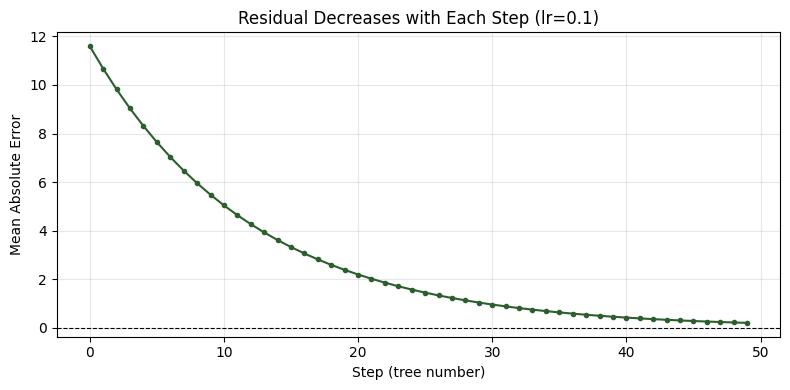

In [7]:
# 잔차 감소 시각화
actual = np.array([80, 65, 90, 50, 75], dtype=float)

mae_history = []
pred = np.full_like(actual, actual.mean())
for _ in range(50):
    residual = actual - pred
    mae_history.append(np.mean(np.abs(residual)))
    pred = pred + 0.1 * (residual * 0.8)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mae_history, "o-", color="#2C5F2D", markersize=3, linewidth=1.5)
ax.set_xlabel("Step (tree number)")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Residual Decreases with Each Step (lr=0.1)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 6. learning_rate 비교 — 조금씩 천천히 배우는 전략
- `learning_rate=1.0`: 각 트리의 예측을 **100% 반영** → 빠르지만 과적합 위험
- `learning_rate=0.1` (기본값): 각 트리의 예측을 **10%만 반영** → 안정적
- `learning_rate=0.01`: 매우 천천히 → 트리가 훨씬 많이 필요

| 비유 | lr=1.0: 매 수마다 판세를 크게 뒤집으려는 공격적 바둑, lr=0.1: 매 수마다 조금씩 유리해지는 신중한 바둑 |

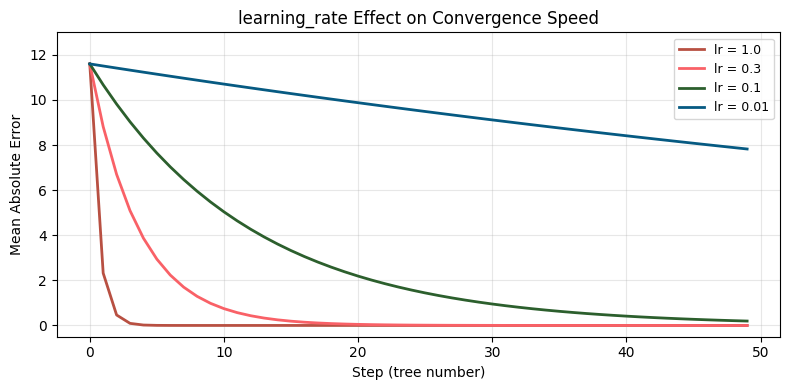

In [8]:
actual = np.array([80, 65, 90, 50, 75], dtype=float)
learning_rates = [1.0, 0.3, 0.1, 0.01]
colors = ["#B85042", "#F96167", "#2C5F2D", "#065A82"]

fig, ax = plt.subplots(figsize=(8, 4))

for lr, color in zip(learning_rates, colors):
    pred = np.full_like(actual, actual.mean())
    mae_list = []
    for _ in range(50):
        residual = actual - pred
        mae_list.append(np.mean(np.abs(residual)))
        pred = pred + lr * (residual * 0.8)
    ax.plot(mae_list, label=f"lr = {lr}", color=color, linewidth=2)

ax.set_xlabel("Step (tree number)")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("learning_rate Effect on Convergence Speed")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 13)
plt.tight_layout()
plt.show()

---
## Step 7. learning_rate × n_estimators 보상 관계
- lr↓ → n↑ (lr × n ≈ 일정한 "총 학습량")

| 조합 | lr | n | 특징 |
|------|-----|------|------|
| A | 1.0 | 10 | 큰 걸음 × 적게 → 빠르지만 과적합 위험 |
| **B** ★ | **0.1** | **100~500** | 적당한 걸음 × 적당히 → **권장** |
| C | 0.01 | 1000+ | 작은 걸음 × 많이 → 안정적이지만 느림 |

**⚠ 랜덤포레스트와 달리, n이 너무 크면 과적합 가능!**

In [9]:
combos = [
    (1.0, 10, "A: lr=1.0, n=10"),
    (0.1, 100, "B: lr=0.1, n=100"),
    (0.1, 300, "B+: lr=0.1, n=300"),
    (0.01, 1000, "C: lr=0.01, n=1000"),
]

print("=== learning_rate × n_estimators 조합 비교 ===")
print(f"{'조합':<28} {'Train':>8} {'Test':>8}")
print("-" * 48)

for lr, n, label in combos:
    model = GradientBoostingClassifier(
        learning_rate=lr, n_estimators=n, max_depth=3, random_state=42
    )
    model.fit(X_train, y_train)
    print(
        f"  {label:<26} "
        f"{model.score(X_train, y_train):>7.4f}  "
        f"{model.score(X_test, y_test):>7.4f}"
    )

print()
print("→ lr=0.1, n=100~300이 train/test 모두 안정적 (권장)")

=== learning_rate × n_estimators 조합 비교 ===
조합                              Train     Test
------------------------------------------------
  A: lr=1.0, n=10             1.0000   0.9386
  B: lr=0.1, n=100            1.0000   0.9561
  B+: lr=0.1, n=300           1.0000   0.9561
  C: lr=0.01, n=1000          1.0000   0.9561

→ lr=0.1, n=100~300이 train/test 모두 안정적 (권장)


---
## Step 8. max_depth 효과 — 얕은 트리를 쓰는 이유
- 랜덤포레스트: 개별 트리를 **깊게** → 강한 학습기(Strong Learner)
- 그래디언트 부스팅: 개별 트리를 **얕게(3~5)** → 약한 학습기(Weak Learner)

| 비유 | "약한 학습기를 합쳐 강한 학습기를 만든다" — Boosting 이름의 어원적 의미 |

### 기대 패턴
| max_depth | Train | Test | 진단 |
|-----------|-------|------|------|
| 3~5 | 높음 | 높음 | **양호** (기본값 구간) |
| 10+ | ≈ 1.0 | 하락 | 과적합 |

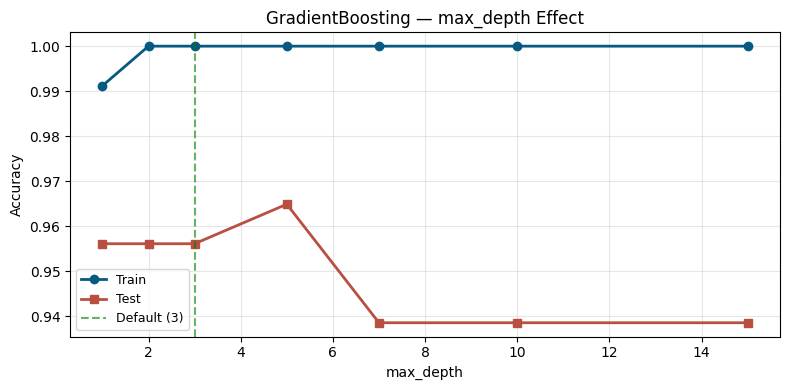

→ max_depth=3~5: train/test 격차 적고 안정적
→ max_depth=10+: train ≈ 1.0이지만 test 하락 = 과적합


In [10]:
depths = [1, 2, 3, 5, 7, 10, 15]
train_scores, test_scores = [], []

for d in depths:
    model = GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=d, random_state=42
    )
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, train_scores, "o-", label="Train", color="#065A82", linewidth=2)
ax.plot(depths, test_scores, "s-", label="Test", color="#B85042", linewidth=2)
ax.axvline(3, color="green", linestyle="--", alpha=0.6, label="Default (3)")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("GradientBoosting — max_depth Effect")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ max_depth=3~5: train/test 격차 적고 안정적")
print("→ max_depth=10+: train ≈ 1.0이지만 test 하락 = 과적합")

---
## Step 9. 배깅 vs. 부스팅 — 4모델 성능 비교
- 동일 데이터, 동일 5-fold 교차검증 → **공정한 비교**
- 편향-분산 관점의 계보: 단일 트리 → 배깅(분산↓) → 부스팅(편향↓+분산↓)

| 전략 | 효과 |
|------|------|
| 단일 트리 (7주차) | 편향↓ 분산↑ — 과적합 위험 높음 |
| 배깅/RF (9주차) | 분산↓ 편향 유지 |
| 부스팅/GB (10주차) | **편향↓ + 분산↓** ★ (단, 튜닝 필수) |

In [11]:
models = {
    "DT (default)": DecisionTreeClassifier(random_state=42),
    "RF (n=100)": RandomForestClassifier(n_estimators=100, random_state=42),
    "GB (default)": GradientBoostingClassifier(random_state=42),
    "GB (tuned)": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
    ),
}

print("=== 4모델 성능 비교 (5-Fold CV) ===")
print(f"{'모델':<16} {'CV 평균':>8} {'± 표준편차':>10} {'Test':>8}")
print("-" * 48)

for name, model in models.items():
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    model.fit(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print(f"  {name:<14} {cv.mean():>7.4f}  {cv.std():>8.4f}  {test_acc:>7.4f}")

print()
print("→ DT: 분산 높음 (과적합)")
print("→ RF: 분산↓ 편향 유지 (배깅)")
print("→ GB: 편향↓ + 분산↓ (부스팅), 튜닝하면 더 향상 가능")

=== 4모델 성능 비교 (5-Fold CV) ===
모델                  CV 평균     ± 표준편차     Test
------------------------------------------------
  DT (default)    0.9165    0.0179   0.9474
  RF (n=100)      0.9582    0.0176   0.9649
  GB (default)    0.9516    0.0164   0.9561
  GB (tuned)      0.9648    0.0128   0.9561

→ DT: 분산 높음 (과적합)
→ RF: 분산↓ 편향 유지 (배깅)
→ GB: 편향↓ + 분산↓ (부스팅), 튜닝하면 더 향상 가능


---
## Step 10. n_estimators 과적합 비교 — RF vs. GB
- **RF**: n을 아무리 키워도 test 성능 안정 → 과적합 안전
- **GB**: n이 커지면 train↑ test 정체/감소 → **과적합 위험!**

**⚠ 이것이 9주차(배깅)와 10주차(부스팅)의 가장 실무적인 차이**

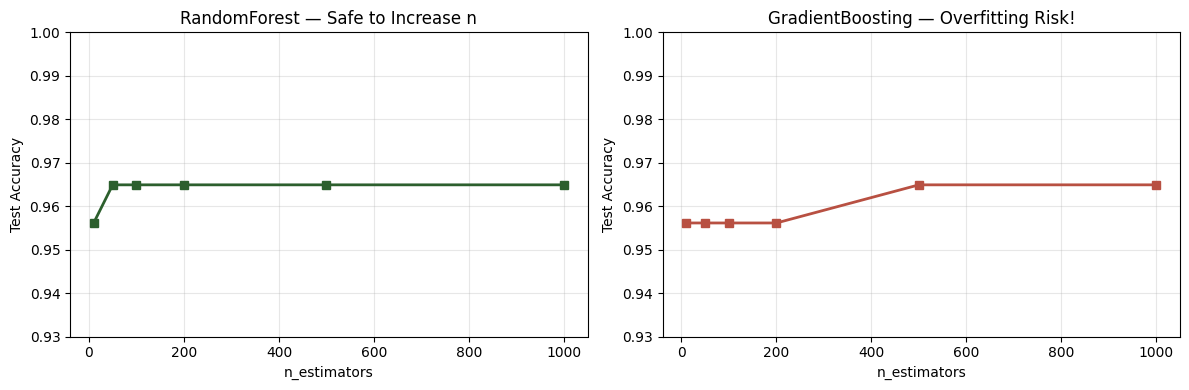

→ RF: n↑ 해도 test 안정
→ GB: n↑ 하면 test 정체/하락 가능 — 튜닝 필수!


In [12]:
n_range = [10, 50, 100, 200, 500, 1000]
rf_test, gb_test = [], []

for n in n_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    rf_test.append(rf.score(X_test, y_test))

    gb = GradientBoostingClassifier(
        n_estimators=n, learning_rate=0.1, max_depth=3, random_state=42
    )
    gb.fit(X_train, y_train)
    gb_test.append(gb.score(X_test, y_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n_range, rf_test, "s-", color="#2C5F2D", linewidth=2, markersize=6)
axes[0].set_title("RandomForest — Safe to Increase n")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_ylim(0.93, 1.0)
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_range, gb_test, "s-", color="#B85042", linewidth=2, markersize=6)
axes[1].set_title("GradientBoosting — Overfitting Risk!")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_ylim(0.93, 1.0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("→ RF: n↑ 해도 test 안정")
print("→ GB: n↑ 하면 test 정체/하락 가능 — 튜닝 필수!")

---
## Step 11. 수동 탐색의 한계 — for문 3중 중첩

7주차(파라미터 1개)는 for문 하나로 충분했지만,
10주차(파라미터 3개)는 for문 3중 중첩이 필요하다.

| 주차 | 파라미터 | for문 | 조합 수 |
|------|----------|-------|---------|
| 7주차 (DT) | `max_depth` 1개 | 1중 ✅ | 15 |
| 9주차 (RF) | `n_estimators` 1개 | 1중 ✅ | 5 |
| 10주차 (GB) | 3개 | **3중 중첩 ❌** | **27** |

### 수동 탐색의 세 가지 문제
1. for문 3중 중첩 → 코드 복잡, 실수 위험
2. 27개 결과를 체계적으로 저장·비교하기 어려움
3. 모든 조합의 fold 분할이 동일해야 공정 비교 → 수동 보장 어려움

In [13]:
# 7주차 방식: for문 1개 (간단)
print("=== 7주차 방식: 파라미터 1개 → for문 1개 ===")
for depth in [1, 3, 5, 7, 10]:
    scores = cross_val_score(
        DecisionTreeClassifier(max_depth=depth, random_state=42),
        X_train, y_train, cv=5,
    )
    print(f"  max_depth={depth:>2}  →  CV: {scores.mean():.4f}")

print("→ for문 1개, 5개 조합 = 간단")

=== 7주차 방식: 파라미터 1개 → for문 1개 ===
  max_depth= 1  →  CV: 0.8879
  max_depth= 3  →  CV: 0.9319
  max_depth= 5  →  CV: 0.9253
  max_depth= 7  →  CV: 0.9187
  max_depth=10  →  CV: 0.9165
→ for문 1개, 5개 조합 = 간단


In [14]:
# 10주차 방식: for문 3중 중첩 (복잡)
print("=== 10주차 방식: 파라미터 3개 → for문 3중 중첩 ===")

n_list = [50, 100, 200]
lr_list = [0.01, 0.1, 0.2]
depth_list = [3, 5, 7]

manual_results = []
for n in n_list:
    for lr in lr_list:
        for d in depth_list:
            model = GradientBoostingClassifier(
                n_estimators=n, learning_rate=lr,
                max_depth=d, random_state=42,
            )
            scores = cross_val_score(model, X_train, y_train, cv=5)
            manual_results.append({
                "n": n, "lr": lr, "depth": d,
                "cv_mean": scores.mean(),
            })

total = len(n_list) * len(lr_list) * len(depth_list)
best_row = pd.DataFrame(manual_results).sort_values(
    "cv_mean", ascending=False
).iloc[0]

print(f"  총 {total}개 조합 × 5-fold = {total * 5}번 학습 완료")
print(
    f"  수동 최적: n={int(best_row['n'])}, lr={best_row['lr']}, "
    f"depth={int(best_row['depth'])} → CV: {best_row['cv_mean']:.4f}"
)
print()
print("→ for문 3중 중첩 + 결과 관리 코드 = 복잡하고 실수 위험")
print("→ GridSearchCV가 이 문제를 한 번에 해결한다")

=== 10주차 방식: 파라미터 3개 → for문 3중 중첩 ===
  총 27개 조합 × 5-fold = 135번 학습 완료
  수동 최적: n=200, lr=0.1, depth=3 → CV: 0.9648

→ for문 3중 중첩 + 결과 관리 코드 = 복잡하고 실수 위험
→ GridSearchCV가 이 문제를 한 번에 해결한다


---
## Step 12. GridSearchCV 실행
- `GridSearchCV`: param_grid의 모든 조합을 교차검증으로 자동 평가
- scikit-learn의 **모든 모델**에 사용 가능 (DT, RF, GB, LR, SVM 등)

### 입력 → 자동 실행 → 출력
| 입력 (내가 정함) | 자동 실행 | 출력 (내가 받음) |
|---|---|---|
| ① 모델 (값 **안** 넣음) | 모든 조합 생성 (Grid) | `best_params_` |
| ② param_grid (딕셔너리) | 각 조합 × 교차검증 | `best_score_` |
| ③ cv, scoring | 최적 선택 + 전체 데이터 재학습 | `best_estimator_` |

**⚠ fit() 전에 반드시: 조합 수 × fold 수 = 총 학습 횟수 미리 계산!**

⚠ 흔한 실수: `'n_estimator'`(s 없음), `'lr'`(줄임말) → 파라미터명 오타 시 에러!

In [15]:
model = GradientBoostingClassifier(random_state=42)  # ← 값 넣지 않음

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
}

# fit() 전에 반드시 확인
n_combos = 3 * 3 * 3
print(f"조합 수: {n_combos}, 총 학습: {n_combos} × 5 = {n_combos * 5}번")
print()

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    refit=True,              # 최적 조합으로 전체 데이터 재학습 (기본값)
    return_train_score=True,
)
grid_search.fit(X_train, y_train)

print("=== GridSearchCV 결과 ===")
print(f"  best_params_    : {grid_search.best_params_}")
print(f"  best_score_ (CV): {grid_search.best_score_:.4f}")

조합 수: 27, 총 학습: 27 × 5 = 135번

=== GridSearchCV 결과 ===
  best_params_    : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  best_score_ (CV): 0.9648


---
## Step 13. 결과 상세 분석 — cv_results_
- `cv_results_`에 **전 조합의 상세 결과**가 저장됨
- DataFrame으로 변환하면 정렬·필터링·시각화 가능
- `rank_test_score`가 1인 조합 = best_params_

In [16]:
results_df = pd.DataFrame(grid_search.cv_results_)

summary = results_df[[
    "param_n_estimators", "param_learning_rate", "param_max_depth",
    "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score",
]].sort_values("rank_test_score")

summary.columns = [
    "n_estimators", "learning_rate", "max_depth",
    "CV Mean", "CV Std", "Train Mean", "Rank",
]

print("=== 전체 27개 조합 결과 (상위 10개) ===")
print(summary.head(10).to_string(index=False))

=== 전체 27개 조합 결과 (상위 10개) ===
 n_estimators  learning_rate  max_depth  CV Mean   CV Std  Train Mean  Rank
          200           0.10          3 0.964835 0.012815    1.000000     1
          100           0.20          3 0.960440 0.014906    1.000000     2
          200           0.20          3 0.958242 0.014579    1.000000     3
           50           0.20          3 0.953846 0.014579    1.000000     4
          100           0.10          3 0.951648 0.016447    1.000000     5
           50           0.10          3 0.951648 0.016447    1.000000     5
           50           0.01          5 0.945055 0.023051    0.993956     7
          100           0.10          5 0.942857 0.018906    1.000000     8
          200           0.10          5 0.940659 0.014906    1.000000     9
           50           0.01          3 0.940659 0.019160    0.982418     9


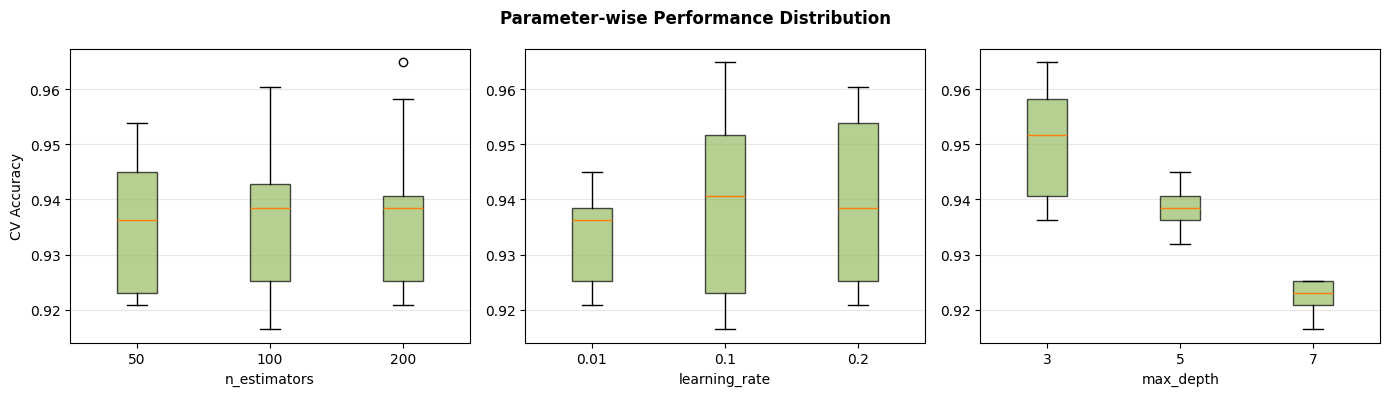

In [17]:
# 파라미터별 성능 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
params = ["param_n_estimators", "param_learning_rate", "param_max_depth"]
labels = ["n_estimators", "learning_rate", "max_depth"]

for ax, param, label in zip(axes, params, labels):
    unique_vals = sorted(results_df[param].unique())
    data_groups = [
        results_df.loc[results_df[param] == v, "mean_test_score"].values
        for v in unique_vals
    ]
    bp = ax.boxplot(
        data_groups, labels=[str(v) for v in unique_vals],
        patch_artist=True,
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("#97BC62")
        patch.set_alpha(0.7)
    ax.set_xlabel(label)
    ax.set_ylabel("CV Accuracy" if param == params[0] else "")
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Parameter-wise Performance Distribution", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 14. 경계값 확인 — best_params_ 해석
- best가 후보의 **가장자리**에 있으면 → 그 방향으로 범위 확장 재탐색 필요
- best가 **중간값**이면 → 격자 설계가 적절했다는 신호

| 위치 | 의미 |
|------|------|
| 가장자리 (min 또는 max) | ⚠ "더 좋은 값이 있을 수 있다" — 확장 재탐색 |
| 중간 | ✓ 양쪽에 더 좋은 값 없음 — 격자 OK |

**⚠ best_params_는 "내 격자 안의 최적"이지 절대적 최적이 아니다**

In [18]:
print("=== best_params_ 경계값 확인 ===")
best = grid_search.best_params_

for param_name, candidates in param_grid.items():
    best_val = best[param_name]
    is_min = best_val == min(candidates)
    is_max = best_val == max(candidates)
    if is_min or is_max:
        status = "⚠ 경계값 → 범위 확장 필요"
    else:
        status = "✓ 중간값 → OK"
    print(f"  {param_name:<16}: best={best_val}, 후보={candidates} → {status}")

print()
print("→ 경계값이 있으면 그 방향으로 후보를 확장하여 재탐색")

=== best_params_ 경계값 확인 ===
  n_estimators    : best=200, 후보=[50, 100, 200] → ⚠ 경계값 → 범위 확장 필요
  learning_rate   : best=0.1, 후보=[0.01, 0.1, 0.2] → ✓ 중간값 → OK
  max_depth       : best=3, 후보=[3, 5, 7] → ⚠ 경계값 → 범위 확장 필요

→ 경계값이 있으면 그 방향으로 후보를 확장하여 재탐색


---
## Step 15. 최종 비교 — 랜덤포레스트와 직접 비교
- `best_estimator_`는 이미 전체 훈련 데이터로 **학습 완료** → 바로 predict() 가능
- 9주차 RandomForest(기본값)와 동일 테스트 데이터에서 비교

**⚠ 이 결과는 특정 데이터셋에서의 비교입니다.
어떤 모델이 무조건 좋은 것은 아닙니다.
항상 둘 다 시도하고 교차검증으로 비교하는 것이 정답입니다.**

In [19]:
best_gb = grid_search.best_estimator_
y_pred_gb = best_gb.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="accuracy")

print("=" * 55)
print("최종 비교: GradientBoosting (tuned) vs RandomForest")
print("=" * 55)
print(f"{'모델':<28} {'CV 평균':>8} {'Test':>8}")
print("-" * 55)
print(f"  {'GB (GridSearchCV 최적)':<26} "
      f"{grid_search.best_score_:>7.4f}  "
      f"{accuracy_score(y_test, y_pred_gb):>7.4f}")
print(f"  {'RF (default, n=100)':<26} "
      f"{rf_cv.mean():>7.4f}  "
      f"{accuracy_score(y_test, y_pred_rf):>7.4f}")
print()
print(f"GB best_params: {grid_search.best_params_}")

최종 비교: GradientBoosting (tuned) vs RandomForest
모델                              CV 평균     Test
-------------------------------------------------------
  GB (GridSearchCV 최적)        0.9648   0.9561
  RF (default, n=100)         0.9582   0.9649

GB best_params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [20]:
# Classification Report 비교
print("=== GradientBoosting (tuned) ===")
print(classification_report(
    y_test, y_pred_gb, target_names=data.target_names
))

print("=== RandomForest (default) ===")
print(classification_report(
    y_test, y_pred_rf, target_names=data.target_names
))

=== GradientBoosting (tuned) ===
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

=== RandomForest (default) ===
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



---
## Step 16. GridSearchCV vs. RandomizedSearchCV
- `GridSearchCV`: 모든 조합을 빠짐없이 시도 — **전수 조사**
- `RandomizedSearchCV`: n_iter개만 랜덤으로 시도 — **표본 조사**

| | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| 장점 | 격자 안 최적 **반드시** 발견 | 시간 예측 가능 (n_iter 고정) |
| 단점 | 조합 수 폭발 위험 | 최적을 놓칠 수 있음 (확률적) |
| 기준 | 조합 **100개 이하** | 조합 **수백~수천 개** |

### 조합 수 폭발 예시
| 구성 | 조합 | 5-fold 학습 | 예상 시간 (1회=5초) |
|------|------|------------|-------------------|
| 3파라미터 × 후보 3개 | 27 | 135 | ~4분 |
| 3파라미터 × 후보 4개 | 64 | 320 | ~27분 |
| 5파라미터 × 후보 4개 | 1,024 | 5,120 | ~8시간 |

In [ ]:
param_grid_large = {
    "n_estimators": [50, 100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2],
    "max_depth": [2, 3, 4, 5, 7],
}
total_combos = 5 * 5 * 5  # 125

# GridSearchCV (전수 조사)
t0 = time.time()
grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_large, cv=5, scoring="accuracy",
)
grid.fit(X_train, y_train)
grid_time = time.time() - t0

# RandomizedSearchCV (20개만)
t0 = time.time()
rand = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_large, n_iter=20, cv=5,
    scoring="accuracy", random_state=42,
)
rand.fit(X_train, y_train)
rand_time = time.time() - t0

print("=== GridSearchCV vs RandomizedSearchCV ===")
print(f"{'':>22} {'Grid':>12} {'Random':>12}")
print("-" * 48)
print(f"  {'조합 탐색 수':>20} {total_combos:>12} {20:>12}")
print(f"  {'총 학습 횟수':>20} {total_combos * 5:>12} {20 * 5:>12}")
print(f"  {'소요 시간 (초)':>20} {grid_time:>12.1f} {rand_time:>12.1f}")
print(f"  {'best_score_':>20} {grid.best_score_:>12.4f} {rand.best_score_:>12.4f}")
print()
print("→ 조합 100개 이하 → GridSearchCV")
print("→ 수백 이상 → RandomizedSearchCV가 효율적")

In [ ]:
print("=" * 60)
print("10주차 그래디언트 부스팅 & GridSearchCV 실습 완료")
print("=" * 60)
print()
print("⚠ 주의: 이 결과는 특정 데이터셋에서의 비교입니다.")
print("  어떤 모델이 무조건 좋은 것은 아닙니다.")
print("  항상 여러 모델을 시도하고 교차검증으로 비교하는 것이 정답입니다.")